In [2]:
import sys
sys.path.append("../")
from data_prep import load_laps

test = load_laps(year=2023, session_name='Sprint')
print(len(test))

2170


In [3]:
import sys
sys.path.append("../")
from data_prep import load_laps, load_session_results, check_missing_sessions, load_pit_stops, dbset

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

- [ ] Why do some drivers/teams consistently qualify better than others is it car pace or driver skill? (compare teammates' qualifying deltas across a season  same car, isolates driver effect)
- [ ] How strongly does grid position actually predict finishing position? (simple linear regression, R², correlation coefficient)
- [ ] Does grid position's predictive power vary by circuit type (street vs. permanent, high-overtaking vs. processional)? (subgroup regression / interaction term)

- [X] How strongly does grid position actually predict finishing position? (simple linear regression, R², correlation coefficient)

In [51]:
import pandas as pd
from scipy import stats
import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

query = """
SELECT gs.year, gm.meeting_name, g.driver_number,
       g."position" AS grid_position,
       sr."position" AS final_position
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
JOIN silver_meetings gm ON gs.meeting_key = gm.meeting_key
JOIN silver_sessions rs ON rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race'
JOIN silver_session_result sr ON sr.session_key = rs.session_key AND sr.driver_number = g.driver_number
WHERE gs.session_name = 'Qualifying'
  AND sr.dns = 0 AND sr.dnf = 0 AND sr.dsq = 0
  AND sr."position" IS NOT NULL
"""

df = pd.read_sql(query, conn)
df

,year,meeting_name,driver_number,grid_position,final_position
0,2023,Saudi Arabian Grand Prix,11,1,1
1,2023,Saudi Arabian Grand Prix,1,15,2
2,2023,Saudi Arabian Grand Prix,14,2,3
3,2023,Saudi Arabian Grand Prix,63,3,4
4,2023,Saudi Arabian Grand Prix,44,7,5
...,...,...,...,...,...
1167,2026,Austrian Grand Prix,87,13,14
1168,2026,Austrian Grand Prix,43,16,15
1169,2026,Austrian Grand Prix,31,15,16
1170,2026,Austrian Grand Prix,23,18,17


<Axes: xlabel='grid_position', ylabel='final_position'>

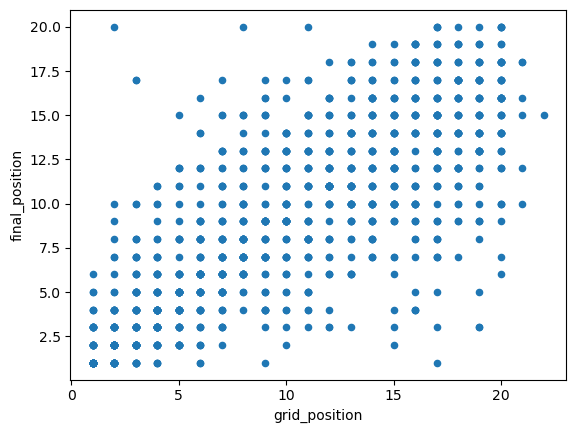

In [52]:
df.plot.scatter(x='grid_position', y='final_position')

slope: 0.682
intercept: 2.270
r (correlation): 0.768
R^2: 0.590
p-value: 7.63e-229
stderr: 0.017


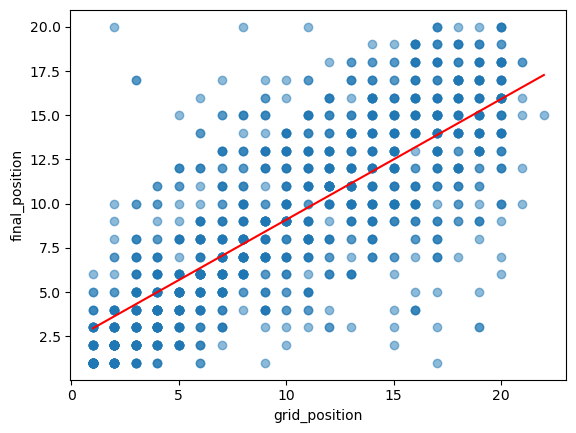

In [53]:
import matplotlib.pyplot as plt
from scipy import stats

result = stats.linregress(df['grid_position'], df['final_position'])

print(f"slope: {result.slope:.3f}")
print(f"intercept: {result.intercept:.3f}")
print(f"r (correlation): {result.rvalue:.3f}")
print(f"R^2: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.2e}")
print(f"stderr: {result.stderr:.3f}")


fig, ax = plt.subplots()
ax.scatter(df['grid_position'], df['final_position'], alpha=0.5)
x_line = df['grid_position'].sort_values()
ax.plot(x_line, result.slope * x_line + result.intercept, color='red')
ax.set_xlabel('grid_position')
ax.set_ylabel('final_position')
plt.show()

Grid position explains 59% of the variation we see in finishing positions across all drivers and races. The remaining 41% is due to other factors like race incidents, strategy, pace, weather, etc.


---

Scope: Race sessions only, DNS/DNF/DSQ excluded , isolates the "clean race" effect.

slope: 0.682     -> On average, each grid place further back costs ~0.68 finishing 
                    places. NOT a percentage, not a measure of prediction quality ,
                    it's a rate (units: finish-positions per grid-position).

intercept: 2.270  -> Predicted finish position at grid_position = 0. Not physically
                    meaningful here (grid starts at 1) , just an artifact of the line.

r: 0.768          -> Correlation strength/direction. Matches df.corr() exactly,
                    that's the sanity check that linregress and pandas agree.

R^2: 0.590        -> THE "how good is this model" number. 59% of the variance in
                    finish position is explained by grid position alone. The other
                    41% is strategy, incidents, pace, luck, weather, etc. This is
                    the number to quote when someone asks "how strong is the effect."

p-value: 7.63e-229 -> Answers a DIFFERENT question than R²: "is the slope definitely
                    not zero?" Tiny p-value = yes, essentially certain. It does NOT
                    mean the model is accurate or the effect is large ,with a big
                    enough sample, even a weak real effect gets a tiny p-value.
                    TRAP: don't read a small p-value as "strong effect." That's R²'s job.

stderr: 0.017     -> Standard error of the SLOPE estimate (analytic, not bootstrapped 
                    , linregress computes this directly from the residuals/sample size).
                    Small stderr = the slope (0.682) is precisely pinned down; if I
                    reran this on a different sample of races, I'd expect a similar
                    slope. This is about confidence in the SLOPE VALUE, not about how
                    well the model predicts individual outcomes. TRAP: precision of an
                    estimate =/= strength of a relationship — those are independent.

TAKEAWAY: Grid position has a real, precisely-measured, statistically certain effect
on finishing position (p-value, stderr) , but that effect is moderate in strength
(R²=0.59), leaving considerable room for race-day factors to still change the outcome.

RULE OF THUMB for every regression from here on:
- R² -> strength of the relationship (how good is prediction)
- p-value / stderr -> confidence that the slope is real and well-estimated
  (NOT how good the model is)
These two axes are independent. A model can be "certainly real, but weak"
(common with large samples) or "uncertain but potentially strong" (common
with small samples) — never assume one implies the other.

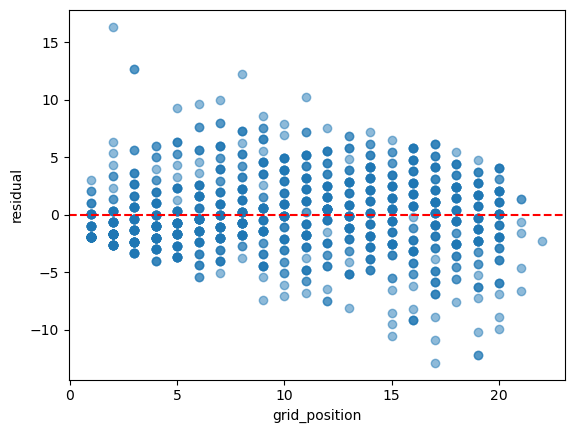

In [14]:
fig, ax = plt.subplots()
ax.scatter(df['grid_position'], df['residual'], alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('grid_position')
ax.set_ylabel('residual')
plt.show()

Residual spread is NOT uniform across grid_position (heteroscedasticity confirmed).
Narrowest at grid extremes (P1-3, P18+), widest in the midfield (P5-17).
Implication: R²=0.59 is an average fit quality , front-row starts are more
predictable than midfield starts. A single linear model slightly understates
predictability at the front and overstates it in the middle.

<Axes: >

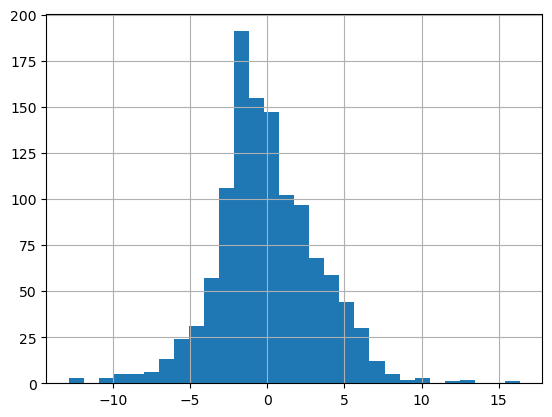

In [15]:
df['residual'].hist(bins=30)

- [X] Why do some drivers/teams consistently qualify better than others is it car pace or driver skill? (compare teammates' qualifying deltas across a season  same car, isolates driver effect)

In [20]:

query = """

  WITH quali AS (
    SELECT g.session_key, g.driver_number, d.team_name, d.full_name,
           g.lap_duration, s.year, m.meeting_name, m.date_start
    FROM silver_starting_grid g
    JOIN silver_sessions s ON g.session_key = s.session_key
    JOIN silver_meetings m ON s.meeting_key = m.meeting_key
    JOIN silver_drivers d ON g.session_key = d.session_key AND g.driver_number = d.driver_number
    WHERE s.session_name = 'Qualifying'
      AND g.lap_duration IS NOT NULL
)
SELECT q1.year, q1.meeting_name, q1.team_name,
       q1.full_name AS driver_a, q1.lap_duration AS time_a,
       q2.full_name AS driver_b, q2.lap_duration AS time_b,
       q1.lap_duration - q2.lap_duration AS delta
FROM quali q1
JOIN quali q2
    ON q1.session_key = q2.session_key
    AND q1.team_name = q2.team_name
    AND q1.driver_number < q2.driver_number
ORDER BY q1.year, q1.meeting_name, q1.team_name;
"""

df = pd.read_sql(query, conn)
df

,year,meeting_name,team_name,driver_a,time_a,driver_b,time_b,delta
0,2023,Abu Dhabi Grand Prix,Alfa Romeo,ZHOU Guanyu,85.159,Valtteri BOTTAS,84.788,0.371
1,2023,Abu Dhabi Grand Prix,AlphaTauri,Daniel RICCIARDO,84.442,Yuki TSUNODA,83.968,0.474
2,2023,Abu Dhabi Grand Prix,Alpine,Pierre GASLY,84.548,Esteban OCON,84.391,0.157
3,2023,Abu Dhabi Grand Prix,Aston Martin,Fernando ALONSO,84.084,Lance STROLL,84.422,-0.338
4,2023,Abu Dhabi Grand Prix,Ferrari,Charles LECLERC,83.584,Carlos SAINZ,84.738,-1.154
...,...,...,...,...,...,...,...,...
668,2026,Monaco Grand Prix,McLaren,Lando NORRIS,72.765,Oscar PIASTRI,72.624,0.141
669,2026,Monaco Grand Prix,Mercedes,Kimi ANTONELLI,72.051,George RUSSELL,72.445,-0.394
670,2026,Monaco Grand Prix,Racing Bulls,Liam LAWSON,73.412,Arvid LINDBLAD,74.248,-0.836
671,2026,Monaco Grand Prix,Red Bull Racing,Max VERSTAPPEN,72.094,Isack HADJAR,72.434,-0.340


In [19]:
df['delta'].describe()

count    673.000000
mean      -0.027744
std        3.381517
min      -62.297000
25%       -0.474000
50%       -0.066000
75%        0.319000
max       38.516000
Name: delta, dtype: float64

In [21]:
q1 = df['delta'].quantile(0.25)
q3 = df['delta'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"IQR: {iqr:.3f}")
print(f"Fence: [{lower_fence:.3f}, {upper_fence:.3f}]")

outliers = df[(df['delta'] < lower_fence) | (df['delta'] > upper_fence)]
print(f"Outliers: {len(outliers)} of {len(df)} rows ({len(outliers)/len(df):.1%})")

df_clean = df[(df['delta'] >= lower_fence) & (df['delta'] <= upper_fence)]

IQR: 0.793
Fence: [-1.663, 1.508]
Outliers: 54 of 673 rows (8.0%)


In [22]:
outliers[['year','meeting_name','team_name','driver_a','time_a','driver_b','time_b','delta']].sort_values('delta').head(10)

,year,meeting_name,team_name,driver_a,time_a,driver_b,time_b,delta
25,2023,Austrian Grand Prix,Red Bull Racing,Max VERSTAPPEN,64.391,Sergio PEREZ,126.688,-62.297
50,2023,Belgian Grand Prix,Haas F1 Team,Kevin MAGNUSSEN,114.160,Nico HULKENBERG,123.166,-9.006
68,2023,Canadian Grand Prix,Ferrari,Charles LECLERC,80.615,Carlos SAINZ,89.294,-8.679
76,2023,Dutch Grand Prix,Aston Martin,Fernando ALONSO,71.506,Lance STROLL,80.121,-8.615
521,2025,Las Vegas Grand Prix,Red Bull Racing,Max VERSTAPPEN,108.257,Yuki TSUNODA,116.798,-8.541
515,2025,Las Vegas Grand Prix,Ferrari,Charles LECLERC,109.872,Lewis HAMILTON,117.115,-7.243
383,2024,São Paulo Grand Prix,Williams,Alexander ALBON,84.657,Franco COLAPINTO,91.270,-6.613
69,2023,Canadian Grand Prix,Haas F1 Team,Kevin MAGNUSSEN,81.678,Nico HULKENBERG,87.102,-5.424
66,2023,Canadian Grand Prix,Alpine,Pierre GASLY,82.886,Esteban OCON,87.945,-5.059
376,2024,São Paulo Grand Prix,Ferrari,Charles LECLERC,84.525,Carlos SAINZ,89.406,-4.881


In [23]:
df_clean['delta'].describe()

count    619.000000
mean      -0.085835
std        0.573221
min       -1.632000
25%       -0.420000
50%       -0.067000
75%        0.278000
max        1.501000
Name: delta, dtype: float64

In [39]:
results = []

for (da, db), group in df_clean.groupby(['driver_a', 'driver_b']):
    n = len(group)
    if n < 8: 
        continue
    t_stat, p_value = stats.ttest_1samp(group['delta'], popmean=0)
    results.append({
        'driver_a': da,
        'driver_b': db,
        'team_name': group['team_name'].iloc[0],
        'n_races': n,
        'mean_delta': group['delta'].mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    })

pair_results = pd.DataFrame(results).sort_values('p_value')
pair_results

,driver_a,driver_b,team_name,n_races,mean_delta,t_stat,p_value,significant
6,Fernando ALONSO,Lance STROLL,Aston Martin,65,-0.471123,-7.892649,4.984495e-11,True
14,Max VERSTAPPEN,Sergio PEREZ,Red Bull Racing,32,-0.652813,-7.599775,1.439599e-08,True
15,Max VERSTAPPEN,Yuki TSUNODA,Red Bull Racing,17,-0.819882,-9.939429,2.988959e-08,True
13,Logan SARGEANT,Alexander ALBON,Williams,22,0.559409,5.471574,1.986059e-05,True
20,ZHOU Guanyu,Valtteri BOTTAS,Alfa Romeo,32,0.319937,3.894191,4.897751e-04,True
11,Lando NORRIS,Oscar PIASTRI,McLaren,63,-0.189143,-3.285682,1.676727e-03,True
3,Charles LECLERC,Lewis HAMILTON,Ferrari,26,-0.188154,-3.429281,2.107220e-03,True
10,Kimi ANTONELLI,George RUSSELL,Mercedes,28,0.240750,3.148247,3.982674e-03,True
18,Pierre GASLY,Franco COLAPINTO,Alpine,21,-0.291143,-2.440719,2.408635e-02,True
19,Yuki TSUNODA,Liam LAWSON,AlphaTauri,8,-0.503750,-2.750100,2.849986e-02,True


In [40]:
n_tests = len(pair_results)
alpha_corrected = 0.05 / n_tests

pair_results['significant_bonferroni'] = pair_results['p_value'] < alpha_corrected

print(f"n_tests: {n_tests}")
print(f"alpha_corrected: {alpha_corrected:.5f}")
print()
print("Survivors after Bonferroni correction:")
pair_results[pair_results['significant_bonferroni']][['driver_a','driver_b','team_name','n_races','mean_delta','p_value']]

n_tests: 21
alpha_corrected: 0.00238

Survivors after Bonferroni correction:


,driver_a,driver_b,team_name,n_races,mean_delta,p_value
6,Fernando ALONSO,Lance STROLL,Aston Martin,65,-0.471123,4.984495e-11
14,Max VERSTAPPEN,Sergio PEREZ,Red Bull Racing,32,-0.652813,1.439599e-08
15,Max VERSTAPPEN,Yuki TSUNODA,Red Bull Racing,17,-0.819882,2.988959e-08
13,Logan SARGEANT,Alexander ALBON,Williams,22,0.559409,1.986059e-05
20,ZHOU Guanyu,Valtteri BOTTAS,Alfa Romeo,32,0.319937,4.897751e-04
11,Lando NORRIS,Oscar PIASTRI,McLaren,63,-0.189143,1.676727e-03
3,Charles LECLERC,Lewis HAMILTON,Ferrari,26,-0.188154,2.107220e-03


Row N° 3: 

Across the 17 races where Verstappen and Tsunoda were teammates at Red Bull, Verstappen was consistently about 0.82 seconds faster in qualifying than Tsunoda, on average. This gap is far too large and consistent to be random chance — it's a real, statistically robust performance difference. Since they're driving the same car, this points to a genuine driver skill/pace advantage for Verstappen over Tsunoda specifically, not anything to do with the machinery.



Method: paired qualifying-lap deltas between teammates (identical machinery), one-sample 
t-test per pairing against mean=0. Tukey-fence filtered (Q1/Q3 ±1.5xIQR) beforehand to 
remove non-representative laps (crashes, red flags, deleted laps). 

Pairings with fewer 
than 8 shared qualifying sessions excluded as underpowered. 

Bonferroni correction applied 
across all 21 tested pairings (alpha_corrected = 0.05/21 = 0.00238) to control for the 
multiple-comparisons risk of running many t-tests simultaneously.

RESULT: 7 of 21 teammate pairings show a statistically robust qualifying pace gap that 
survives correction -- since car pace is held constant within a pairing, this isolates 
a real driver skill/pace effect:

  - Verstappen decisively faster than BOTH teammates (Perez: -0.65s, Tsunoda: -0.82s, 
    p<3e-8 both) -- the clearest, most extreme skill signal in the dataset
  - Alonso faster than Stroll (-0.47s, p=4.98e-11) -- largest sample (n=65), most 
    statistically certain result of all
  - Albon faster than Sargeant (+0.56s, p=1.99e-5)
  - Zhou faster than Bottas (+0.32s, p=4.90e-4)
  - Norris faster than Piastri (-0.19s, p=1.68e-3) and Leclerc faster than Hamilton 
    (-0.19s, p=2.11e-3) -- smaller gaps, but backed by large sample sizes (63, 26 
    races), which is why they still clear the strict corrected bar

14 of 21 pairings show NO statistically robust gap once corrected for multiple testing 
-- including some large-sample cases like Hamilton/Russell (n=38) -- suggesting these 
teammates are genuinely close in qualifying pace, not just under-sampled.

TAKEAWAY: since car pace is identical within a pairing, these results support driver 
skill/pace as a real, measurable, and in some cases very large differentiator in 
qualifying performance -- but it's far from universal. Some teammate pairs are 
essentially indistinguishable in pace; others (Verstappen especially) show a 
persistent, large gap that isn't explained by chance or the car.

CAVEAT: This measures a QUALIFYING pace gap specifically. It says nothing about race 
pace, tyre management, or race-day execution -- those are separate diagnostic 
questions further down the list.

- [X] Does grid position's predictive power vary by circuit type (street vs. permanent, high-overtaking vs. processional)? (subgroup regression / interaction term)

In [43]:

query = """

SELECT gs.year, gm.meeting_name, gm.circuit_type, g.driver_number, 
       g."position" AS grid_position, sr."position" AS final_position
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
JOIN silver_meetings gm ON gs.meeting_key = gm.meeting_key
JOIN silver_sessions rs ON rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race'
JOIN silver_session_result sr ON sr.session_key = rs.session_key AND sr.driver_number = g.driver_number
WHERE gs.session_name = 'Qualifying'
  AND gm.circuit_type != 'Temporary - Road'
  AND sr.dns = 0
  AND sr.dnf = 0
  AND sr.dsq = 0
  AND sr."position" IS NOT NULL;
 
"""

df = pd.read_sql(query, conn)
df

,year,meeting_name,circuit_type,driver_number,grid_position,final_position
0,2023,Saudi Arabian Grand Prix,Temporary - Street,11,1,1
1,2023,Saudi Arabian Grand Prix,Temporary - Street,1,15,2
2,2023,Saudi Arabian Grand Prix,Temporary - Street,14,2,3
3,2023,Saudi Arabian Grand Prix,Temporary - Street,63,3,4
4,2023,Saudi Arabian Grand Prix,Temporary - Street,44,7,5
...,...,...,...,...,...,...
1111,2026,Austrian Grand Prix,Permanent,87,13,14
1112,2026,Austrian Grand Prix,Permanent,43,16,15
1113,2026,Austrian Grand Prix,Permanent,31,15,16
1114,2026,Austrian Grand Prix,Permanent,23,18,17


In [45]:
from scipy import stats

for circuit_type, group in df.groupby('circuit_type'):
    result = stats.linregress(group['grid_position'], group['final_position'])
    print(f"{circuit_type} (n={len(group)}):")
    print(f"slope: {result.slope:.3f}")
    print(f"intercept: {result.intercept:.3f}")
    print(f"r: {result.rvalue:.3f}")
    print(f"R²: {result.rvalue**2:.3f}")
    print(f"p-value: {result.pvalue:.2e}")
    print(f"stderr: {result.stderr:.3f}")
    print()

Permanent (n=763):
slope: 0.683
intercept: 2.317
r: 0.767
R²: 0.589
p-value: 6.96e-149
stderr: 0.021

Temporary - Street (n=353):
slope: 0.664
intercept: 2.276
r: 0.762
R²: 0.581
p-value: 2.95e-68
stderr: 0.030



In [49]:
import statsmodels.formula.api as smf

model = smf.ols('final_position ~ grid_position * C(circuit_type)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         final_position   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     525.3
Date:                Wed, 15 Jul 2026   Prob (F-statistic):          1.53e-212
Time:                        12:27:33   Log-Likelihood:                -2918.7
No. Observations:                1116   AIC:                             5845.
Df Residuals:                    1112   BIC:                             5865.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

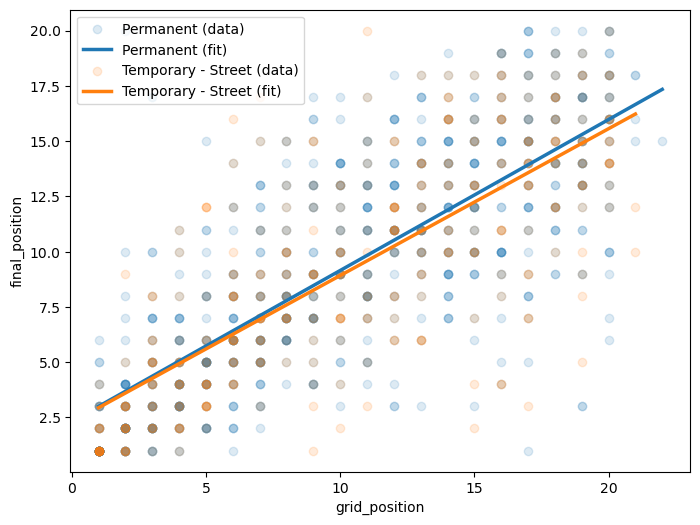

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

colors = {'Permanent': 'tab:blue', 'Temporary - Street': 'tab:orange'}

for circuit_type, group in df.groupby('circuit_type'):
    ax.scatter(group['grid_position'], group['final_position'], 
               alpha=0.15, color=colors[circuit_type], label=f'{circuit_type} (data)')
    
    result = stats.linregress(group['grid_position'], group['final_position'])
    x_line = pd.Series(sorted(group['grid_position'].unique()))
    ax.plot(x_line, result.slope * x_line + result.intercept, 
            color=colors[circuit_type], linewidth=2.5, label=f'{circuit_type} (fit)')

ax.set_xlabel('grid_position')
ax.set_ylabel('final_position')
ax.legend()
plt.show()

Scope: All years 2023-2026, Race sessions, DNS/DNF/DSQ excluded, 
"Temporary - Road" circuit type dropped (only 4 meetings -- too thin to trust).

Method: Two separate simple linear regressions (Permanent vs Temporary - Street), 
then formally tested with a multiple regression including an interaction term 
(final_position ~ grid_position * circuit_type) to check if the slope difference 
is statistically real or just sampling noise.

RESULTS:
  Permanent (n=763):            slope=0.683, R²=0.589
  Temporary - Street (n=353):   slope=0.664, R²=0.581

  Interaction term (grid_position x circuit_type): coef=-0.0186, p=0.612
  -> NOT significant. The small slope difference (0.683 vs 0.664) is consistent 
     with random noise, not a real effect.

  Standalone circuit_type effect (independent of grid position): p=0.923
  -> NOT significant. Street circuits don't shift finish position on their 
     own, once grid position is accounted for.

TAKEAWAY: Grid position predicts finishing position about equally well on 
permanent and street circuits -- no statistically detectable difference at 
this category level, pooling across all seasons 2023-2026. This pushes back 
against the "Monaco/street = grid position matters more" folk wisdom, at 
least when street circuits are grouped together as one category.

CAVEAT / FOLLOW-UP: 
1. A binary street-vs-permanent split may be hiding real circuit-specific 
   effects -- Monaco (extreme, low-overtaking) is grouped with Baku/Jeddah/
   Vegas (higher-overtaking modern street tracks), which could dilute any 
   Monaco-specific signal. A circuit-level (not category-level) regression 
   would be needed to test that properly.
2. Pooling all years together assumes the grid->finish relationship is 
   stable across seasons (car regulation changes, etc. not accounted for). 
   Not tested here -- flagged as a possible future question.